<a href="https://colab.research.google.com/github/unVeroz007/IP-Sems6/blob/main/Pertemuan4/TugasPertemuan4_Image_Processing_MuhammadGalidAvero_2311532008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Import library

In [22]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

#2. Persiapan data


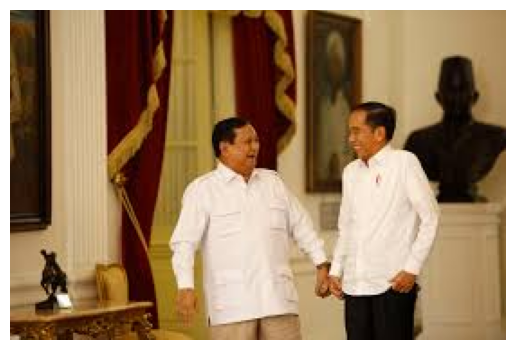

In [33]:
img = Image.open('images (2).jpg')
plt.imshow(img)
plt.axis('off')                      # supaya tidak ada axis
plt.show()

In [24]:
#2 Baca citra
img = Image.open('images (2).jpg').convert('L')  # 'L' = grayscale
img_arr = np.array(img)  # bentuk: (M, N), tipe uint8

In [25]:
# 2. Fungsi hitung histogram manual
def compute_histogram(gray_array):
    # gray_array berisi nilai 0-255
    hist = np.zeros(256, dtype=np.int32)
    for value in gray_array.flatten():
        hist[value] += 1
    return hist

In [26]:
# 3. Fungsi tampilkan citra + histogram
def show_image_and_hist(gray_array, title=''):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(gray_array, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Citra {title}')
    plt.axis('off')

    plt.subplot(1,2,2)
    hist = compute_histogram(gray_array)
    plt.bar(np.arange(256), hist, width=1.0)
    plt.title(f'Histogram {title}')
    plt.xlim(0,255)

    plt.tight_layout()
    plt.show()

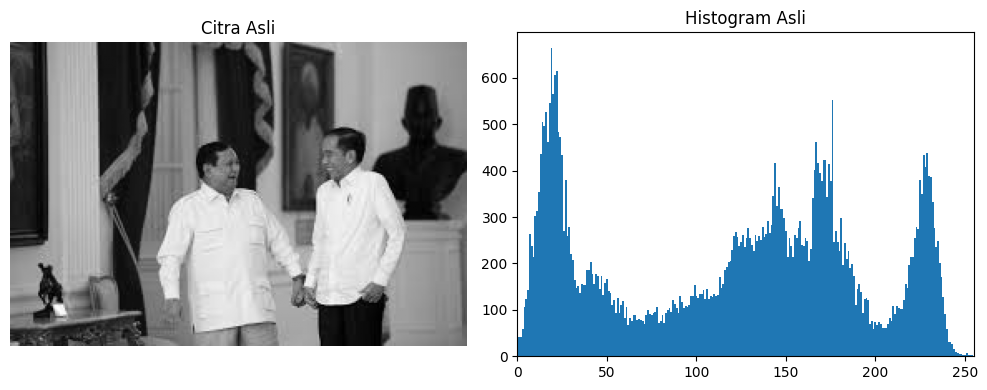

In [27]:
# Tampilkan citra & histogram awal
show_image_and_hist(img_arr, title='Asli')

#3. Normalisasi histogram


In [28]:
def normalize_histogram(gray_array):
    I_min = gray_array.min()
    I_max = gray_array.max()

    # Hindari pembagian nol kalau semua piksel sama
    if I_max == I_min:
        return gray_array.copy()

    # Konversi ke float untuk perhitungan
    norm = (gray_array - I_min) / (I_max - I_min)  # skala 0-1
    norm = (norm * 255).clip(0, 255)              # skala 0-255
    return norm.astype(np.uint8)

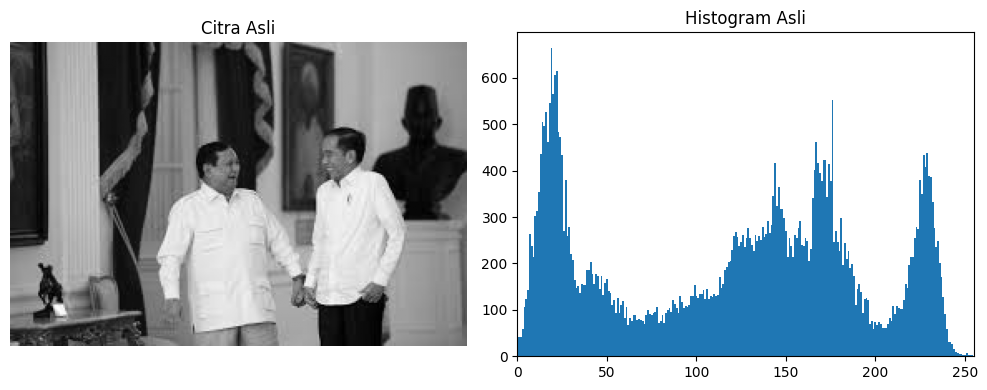

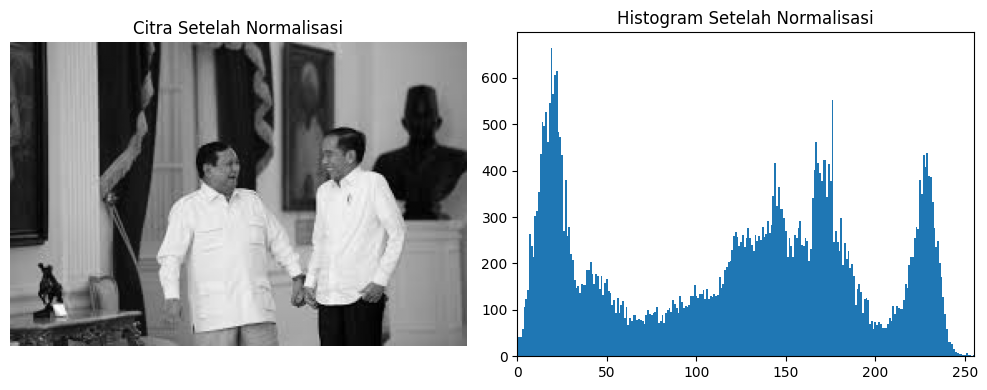

In [29]:
# Terapkan normalisasi
normalized_img = normalize_histogram(img_arr)

# Tampilkan sebelum & sesudah normalisasi
show_image_and_hist(img_arr, title='Asli')
show_image_and_hist(normalized_img, title='Setelah Normalisasi')

#4. Histogram equalization

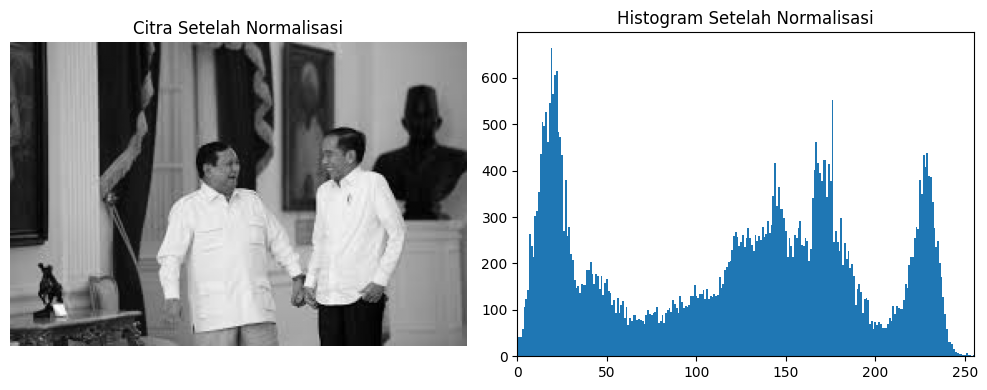

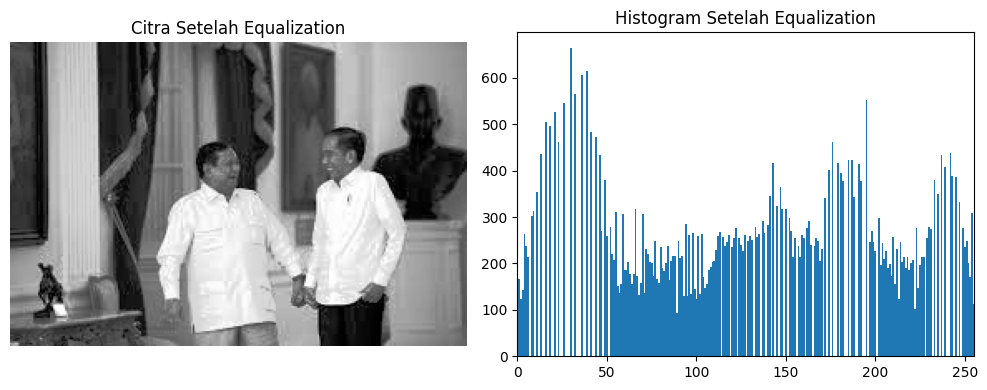

In [30]:
def histogram_equalization(gray_array):
    # 1. Hitung histogram
    hist = compute_histogram(gray_array)
    num_pixels = gray_array.size

    # 2. Normalisasi histogram -> PDF
    pdf = hist / num_pixels  # float, jumlahnya = 1

    # 3. Hitung CDF
    cdf = np.cumsum(pdf)

    # 4. Buat mapping T(k)
    T = np.round(cdf * 255).astype(np.uint8)  # 0-255

    # 5. Terapkan mapping ke seluruh piksel
    flat = gray_array.flatten()
    equalized_flat = T[flat]       # indeks langsung pakai nilai intensitas
    equalized = equalized_flat.reshape(gray_array.shape)

    return equalized, hist, T, cdf

# Terapkan equalization pada citra yang sudah dinormalisasi
equalized_img, hist_norm, T_map, cdf_vals = histogram_equalization(normalized_img)

# Tampilkan hasil
show_image_and_hist(normalized_img, title='Setelah Normalisasi')
show_image_and_hist(equalized_img, title='Setelah Equalization')